In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (downloaded from Kaggle)
df = pd.read_csv('../data/heart_disease_uci.csv')
print("Look at the first 5 patients")
print(df.head())

print("Check for missing values and column data types")
print(df.info())
print("Number of missing values")
print(df.isna().sum())

Look at the first 5 patients
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4      

In [67]:
# --- No imputation: HistGradientBoosting handles missing values natively ---
# slope is ~34% missing, ca ~66%, thal ~53% -- imputing those would fabricate
# a lot of signal, so we leave the gaps in place and let the model handle them.

# Drop the non-predictive ID column
df = df.drop(columns=['id'])

# Binary target: 0 = no disease, 1 = disease (num 1-4 collapse to 1)
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

# Data-quality fix: chol=0 and trestbps=0 are physiologically impossible -- they are
# missing-value placeholders (chol=0 is almost entirely from the Switzerland site, which
# has a 93% disease rate). Recode them to NaN so the model treats them as missing instead
# of learning the artifact "low cholesterol -> disease". (oldpeak/ca zeros are LEFT alone:
# there, 0 is a real, valid value.)
for col in ['chol', 'trestbps']:
    df[col] = df[col].replace(0, np.nan)

# Drop the hospital-site column: disease rate ranges 36%-93% across sites, so keeping it
# lets the model predict "which hospital" instead of "which symptoms" (site leakage).
df = df.drop(columns=['dataset'])

# Binary field as explicit 0/1 (clearer and safer than get_dummies for a two-value column)
df['sex'] = (df['sex'] == 'Male').astype(int)

# Text / boolean categoricals -> pandas 'category' dtype.
# HistGradientBoosting reads these directly and treats NaN as its own category.
categorical_cols = ['cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# All other columns stay numeric; NaNs are intentionally left in place.
print(df.dtypes)
print("\nMissing values kept (NOT imputed):")
print(df.isna().sum())

age            int64
sex            int64
cp          category
trestbps     float64
chol         float64
fbs         category
restecg     category
thalch       float64
exang       category
oldpeak      float64
slope       category
ca           float64
thal        category
target         int64
dtype: object

Missing values kept (NOT imputed):
age           0
sex           0
cp            0
trestbps     60
chol        202
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64


In [68]:
# Features = everything except the target. Category dtypes and NaNs are preserved.
X = df.drop(columns=['target'])
y = df['target']

print(f"Feature matrix: {X.shape[0]} patients x {X.shape[1]} features")
print("Categorical features:", [c for c in X.columns if str(X[c].dtype) == 'category'])

Feature matrix: 920 patients x 13 features
Categorical features: ['cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [69]:
from sklearn.model_selection import train_test_split

# stratify=y keeps the disease/no-disease ratio identical in train and test.
# No StandardScaler -- tree-based models don't need feature scaling.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (736, 13)  Test: (184, 13)


In [70]:
from sklearn.ensemble import HistGradientBoostingClassifier

# categorical_features='from_dtype' auto-detects the 'category' columns (sklearn >= 1.4)
# class_weight='balanced' compensates for the class imbalance.
model = HistGradientBoostingClassifier(
    categorical_features='from_dtype',
    class_weight='balanced',
    random_state=42,
)
model.fit(X_train, y_train)   # X_train still contains NaN -- handled internally
print("Trained on", X_train.shape[1], "features, including the previously-dropped predictors.")

Trained on 13 features, including the previously-dropped predictors.


In [71]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Default threshold (0.50)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8315
ROC-AUC:  0.9035
              precision    recall  f1-score   support

           0       0.82      0.79      0.81        82
           1       0.84      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



In [72]:
# Clinical priority: catch sick patients -> favor recall by lowering the threshold.
# (re-uses y_prob from the previous cell)
y_pred_adjusted = (y_prob >= 0.35).astype(int)

print("--- Adjusted threshold (0.35) ---")
print(classification_report(y_test, y_pred_adjusted))

--- Adjusted threshold (0.35) ---
              precision    recall  f1-score   support

           0       0.90      0.73      0.81        82
           1       0.81      0.93      0.87       102

    accuracy                           0.84       184
   macro avg       0.85      0.83      0.84       184
weighted avg       0.85      0.84      0.84       184



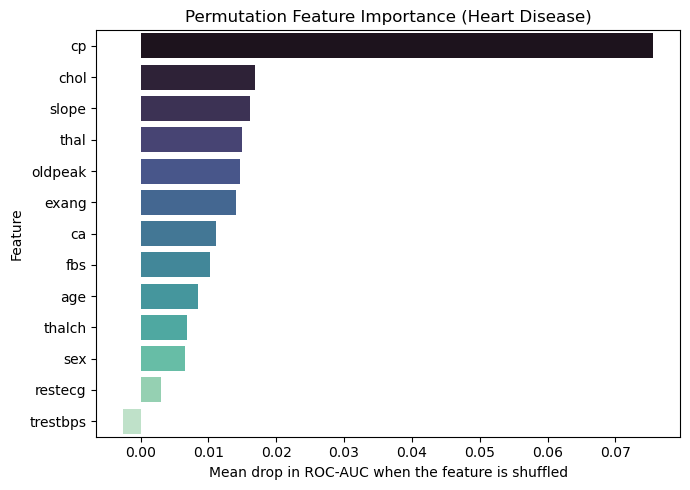

In [73]:
# HistGradientBoosting has no .feature_importances_, so use permutation importance:
# shuffle each feature and measure how much ROC-AUC drops. Model-agnostic and
# more trustworthy than impurity-based importance.
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, scoring='roc_auc'
)
importances = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="mako", legend=False)
plt.title("Permutation Feature Importance (Heart Disease)")
plt.xlabel("Mean drop in ROC-AUC when the feature is shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Explainability with SHAP

Permutation importance (above) tells us which features matter **on average**. SHAP goes further: it explains **every individual prediction** by splitting it into each feature's contribution, in a way that is mathematically guaranteed to add up to the model's output (these are game-theory "Shapley values").

Two views:
- **Beeswarm** — a *global* summary across all test patients.
- **Waterfall** — a *local* explanation of one specific patient's prediction.

*Heads-up:* SHAP and permutation importance can rank features differently — that's expected. Permutation importance measures the drop in ranking ability (ROC-AUC) when a feature is shuffled and tends to under-credit features whose information is recoverable from correlated ones; SHAP measures each feature's direct contribution to the prediction. Seeing both gives a fuller picture.

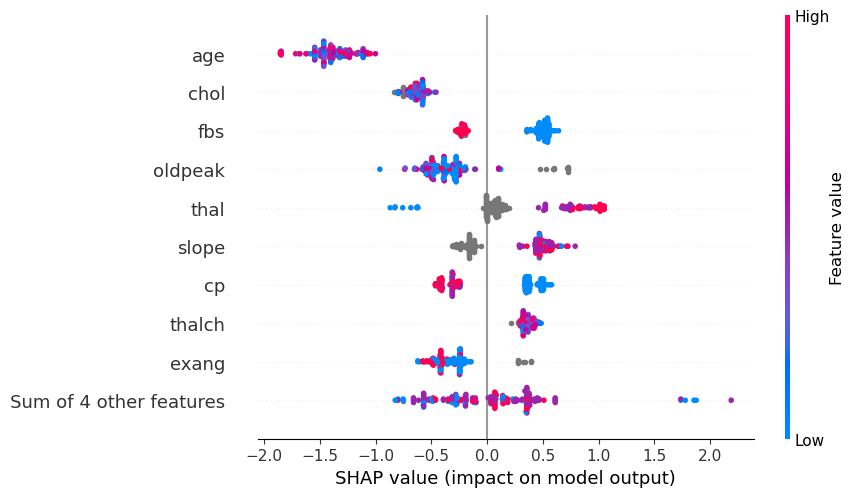

In [74]:
import shap

# SHAP's tree explainer needs NUMERIC input, so convert the category columns to the
# integer codes the model uses internally (missing -> NaN, which the trees handle).
def to_codes(frame):
    out = frame.copy()
    for col in categorical_cols:
        out[col] = out[col].cat.codes.replace(-1, np.nan)
    return out

explainer = shap.TreeExplainer(model)
shap_values = explainer(to_codes(X_test))
shap_values.feature_names = list(X_test.columns)   # keep human-readable names

# Show the ORIGINAL labels (e.g. "asymptomatic" instead of code 3) in the plots.
# SHAP still computes on the numeric codes in shap_values.data; display_data only
# changes what's printed on the charts.
shap_values.display_data = X_test.values

# Beeswarm = GLOBAL summary. Each dot is one patient; horizontal position is how much
# that feature pushed the prediction toward (right) or away from (left) heart disease.
# Color = the feature's value (for categoricals this is still the numeric code).
shap.plots.beeswarm(shap_values, show=True)

Patient #0  ->  predicted probability of heart disease: 0.744
Actual label: 1   (1 = disease, 0 = no disease)


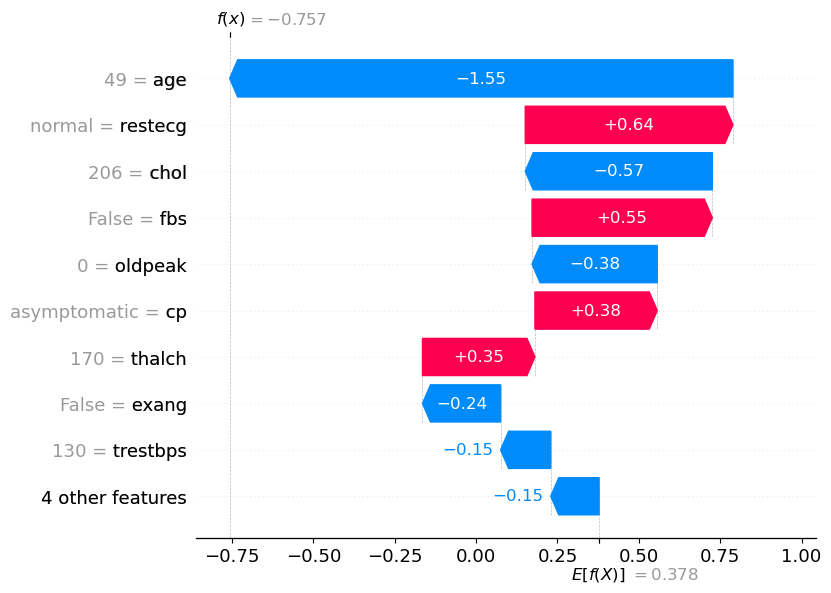

In [75]:
# --- Local explanation: why did the model decide THIS for one patient? ---
patient = 0   # <- change this index to inspect a different test patient

prob = model.predict_proba(X_test.iloc[[patient]])[0, 1]
print(f"Patient #{patient}  ->  predicted probability of heart disease: {prob:.3f}")
print(f"Actual label: {y_test.iloc[patient]}   (1 = disease, 0 = no disease)")

# Waterfall: starts at the average prediction E[f(x)] and adds each feature's
# contribution, one step at a time, until it reaches this patient's final score.
# Red bars push toward disease, blue bars push away.
shap.plots.waterfall(shap_values[patient], show=True)

## SHAP Dependence Plots

The beeswarm squashes each feature onto a single line. A **dependence plot** zooms into one feature and shows the full *shape* of its effect: the x-axis is the feature's value, the y-axis is its SHAP contribution, so each dot is one patient.

- **`oldpeak`** — the missing (NaN) values appear as their own strip; compare where they land vs. the recorded values to *see* the missing-data signal.
- **`age` colored by `thalch`** — coloring by a second feature reveals interactions; here it shows why `age` looked like a flat negative offset in the beeswarm (its signal overlaps with maximum heart rate).

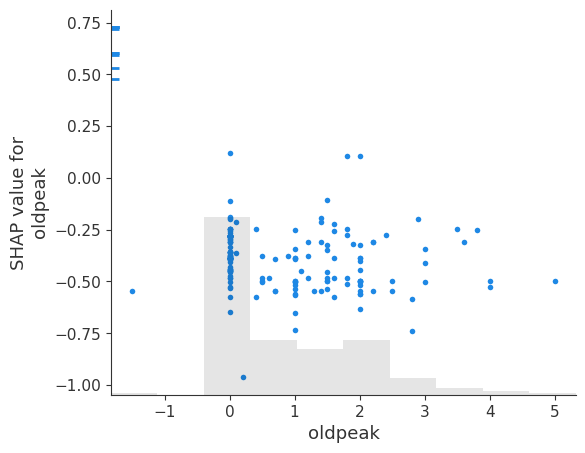

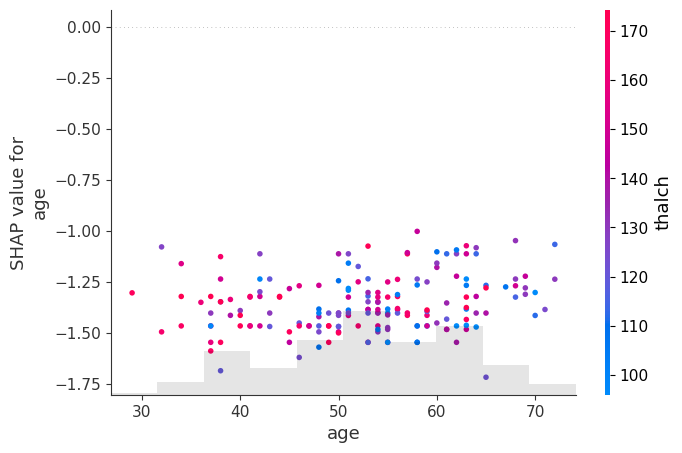

In [76]:
# Dependence plots zoom into ONE feature: x = the feature's value, y = its SHAP push.

# (1) oldpeak -- watch for the separate strip of MISSING values (NaN). If they sit
#     higher (toward disease) than the recorded values, that's the "missing not at
#     random" signal: whether the test was even done is itself predictive.
shap.plots.scatter(shap_values[:, "oldpeak"], show=True)

# (2) age, COLORED by thalch (max heart rate). The vertical spread + color shows the
#     interaction: age's effect is entangled with heart rate (they carry overlapping
#     information), which is why 'age' looked like a flat offset in the beeswarm.
shap.plots.scatter(shap_values[:, "age"], color=shap_values[:, "thalch"], show=True)

In [77]:
# Proof: the detached strip in the oldpeak plot above IS the missing-value patients.
# SHAP can't place a NaN on a number line, so it parks missing points off to the side.
missing_mask  = X_test["oldpeak"].isna().values
oi            = X_test.columns.get_loc("oldpeak")
missing_shap  = shap_values.values[missing_mask, oi]
recorded_shap = shap_values.values[~missing_mask, oi]

print(f"Patients with MISSING oldpeak: {missing_mask.sum()}")
print("Their oldpeak SHAP values:", np.round(np.sort(missing_shap), 2))
print(f"Highest SHAP among the {(~missing_mask).sum()} RECORDED patients: {recorded_shap.max():+.2f}")
print("=> every dot above that line can ONLY be a missing-value patient.")

Patients with MISSING oldpeak: 10
Their oldpeak SHAP values: [0.48 0.53 0.59 0.6  0.6  0.72 0.73 0.73 0.73 0.73]
Highest SHAP among the 174 RECORDED patients: +0.12
=> every dot above that line can ONLY be a missing-value patient.
